In [ ]:
tokens_dict = {
    "Towards General Negotiation Strategies with End-to-End Reinforcement Learning": 6721,
    #"The Unreasonable Effectiveness of Open Science in AI A Replication Study": 5041,
    "Applying and benchmarking a stochastic programming-based bidding strategy for day-ahead hydropower scheduling": 13441,
    "Trajectory-based algorithm selection with warm-starting": 4481,
    "Weighted Initialisation of Evolutionary Instrument and Pitch Detection in Polyphonic Music": 8961,
    "Speeding up neural network robustness verification via algorithm configuration and an optimised mixed integer linear programming solver portfolio": 11201,
    "Guidelines for the Quality Assessment of Energy-Aware NAS Benchmarks": 5601,
    "Revisiting SATZilla Features in 2024": 14561,
    "Empirical Analysis of Upper Bounds for Robustness Distributions using Adversarial Attacks": 15681,
    "Hyperparameter Optimization via Interacting with Probabilistic Circuits": 21841,
    "Incorporating the Cycle Inductive Bias in Masked Autoencoders": 5041,
    "Combining Automated Optimisation of Hyperparameters and Reward Shape": 14561,
    "Instance selection for configuration performance comparison": 7281,
    "Automatic Adjusting Global Similarity Measures in Learning CBR Systems": 8961,
    "HyperSHAP: Shapley Values and Interactions for Explaining Hyperparameter Optimization": 5041,
    #"The Evolution of Conformity, Malleability, and Influence in Simulated Online Agents": 15121,
    "Time Series Representations Classroom (TSRC) A Teacher-Student-based Framework for Interpretability-enhanced Unsupervised Time Series Representation Learning": 24081,
    "Leveraging AutoML for Sustainable Deep Learning: A Multi- Objective HPO Approach on Deep Shift Neural Networks": 16801,
    "Robustness Distributions in Neural Network Verification": 22961,
    "AutoMergeNet- AutoML-Based M-Source Satellite Data Fusion Evaluated With Atmospheric Case Studies": 7281,
    #"Exploring the Integration of Spatial Information into a Spectral Clustering Approach to Unsupervised Band Selection": 5041,
    #"Examining the robustness of Physics-Informed Neural Networks to noise for Inverse Problems": 17921,
    "Dynamic Algorithm Termination for Branch-and-Bound-based Neural Network Verification": 12881,
    "Data Efficient Pre-training for Language Models An Empirical Study of Compute Efficiency and Linguistic Competence": 7841,
    "Audio Classification Models are Vulnerable to Filter Pertubations": 2801,
    "Regularized Feature Selection Landscapes An Empirical Study of Multimodality": 10081,
    "Edge-Based Graph Component Pooling": 8401,
    "Towards Consistent and Efficient Decision-based Attacks": 5601,
    "Rethinking Evaluation Paradigms in IBP-based Certified Training": 21281,
    "Growing with Experience- Growing Neural Networks in Deep Reinforcement Learning": 2801,
    "An Evaluation of Neural Network Architectures for Predicting Hydro Unit Commitment Decisions": 3361,
    "Hyperparameters in Reinforcement Learning and How To Tune Them": 25761,
    "EDC: Equation Discovery for Classification": 8401,
    #"carps- A Framework for Comparing N Hyperparameter Optimizers on M Benchmarks": 19601
}


In [2]:
print(len(set(tokens_dict.values())), len(tokens_dict))

21 28


In [3]:
from pathlib import Path
for key, value in tokens_dict.items():
    if not (Path("reviews") / f"{key}.md").exists():
        print(key)

for review in Path("reviews").glob("*.md"):
    if review.stem not in tokens_dict.keys():
        print("!", review.stem)

/var/folders/78/9cl0kydx0g3cdzjyk28yzr7w0000gn/T/ipykernel_45267/1563163139.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='Field', bbox_to_anchor=(1.02, 1), loc='upper left')


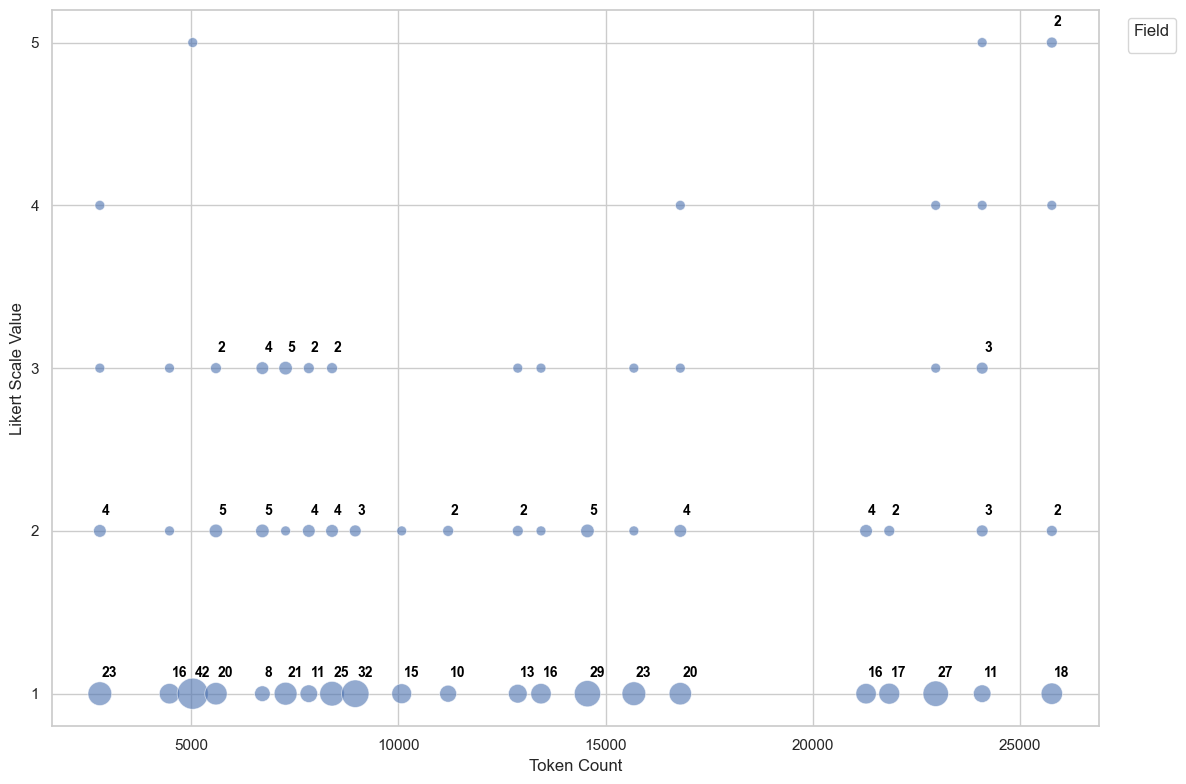

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the dataframe from output.csv
df = pd.read_csv('output.csv')

# --- Map field names for clarity and grouping ---
field_mapping = {
    'Research Question Likert Score': 'Research Question',
    'Hypothesis Likert Score': 'Hypothesis',
    'Experiment Description Likert Score': 'Experiment',
    'Analysis Likert Score': 'Analysis',
    'Interpretation Likert Score': 'Interpretation',
    'Conclusion Likert Score': 'Conclusion',
    'Suggested Research Question Likert Score': 'Future Work',
    'Suggested Hypothesis Likert Score': 'Future Work'
}
df['field'] = df['field'].map(field_mapping)

# --- Map the token counts to the dataframe ---
# Create a 'tokens' column by looking up the (Paper, section) pair in the tokens_dict.
# Note: The user's tokens_dict uses 'Paper' as key, so we map on that.
if isinstance(next(iter(tokens_dict)), str):
    df['tokens'] = df['Paper'].map(tokens_dict)

# Drop rows where there was no matching token count (if any) and ensure tokens are integers
df_plot = df.dropna(subset=['tokens'])
df_plot['tokens'] = df_plot['tokens'].astype(int)

# --- Aggregate data to handle overplotting ---
# Group by coordinates and count occurrences
counts_df = df_plot.groupby(['tokens', 'value']).size().reset_index(name='count')

# --- Create the Scatter Plot ---
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Use scatterplot with size based on point count
ax = sns.scatterplot(
    data=counts_df, 
    x='tokens', 
    y='value', 
    size='count',
    sizes=(50, 500),  # Min and max point sizes
    legend=False,     # We don't need a size legend
    color='b',        # Single color for all points
    alpha=0.6
)

# --- Add count labels to each point ---
for index, row in counts_df.iterrows():
    if row['count'] > 1: # Only label points with more than one occurrence
        ax.text(row['tokens'] + 50, row['value'] + 0.1, str(row['count']), 
                fontdict={'size': 10, 'color': 'black', 'weight': 'bold'})

# --- Formatting and Labels ---
# ax.set_title('Likert Scale Value vs. Token Count by Field', fontsize=16) # Title removed as requested
ax.set_xlabel('Token Count', fontsize=12)
ax.set_ylabel('Likert Scale Value', fontsize=12)

# Set y-axis to only show integer ticks from 1 to 5
ax.set_yticks([1, 2, 3, 4, 5])

# Improve legend
ax.legend(title='Field', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [5]:
from scipy.stats import spearmanr

# Calculate Spearman's rank correlation, which is suitable for an ordinal variable (Likert scale)
# and a continuous variable (token count).
correlation, p_value = spearmanr(df_plot['tokens'], df_plot['value'])

print(f"Spearman's Rank Correlation between Token Count and Likert Scale Value:")
print(f"Correlation Coefficient (rho): {correlation:.4f}")
print(f"P-value: {p_value:.4f}\n")

# --- Interpretation of the Results ---
if p_value < 0.05:
    print("The result is statistically significant (p < 0.05).")
    if correlation > 0.1:
        print("This indicates a weak positive monotonic relationship: as token count increases, the Likert score tends to increase slightly.")
    elif correlation < -0.1:
        print("This indicates a weak negative monotonic relationship: as token count increases, the Likert score tends to decrease slightly.")
    else:
        print("There is a statistically significant relationship, but it is very weak.")
else:
    print("The result is not statistically significant (p >= 0.05).")
    print("We cannot conclude that there is a monotonic relationship between token count and Likert scale value.")

Spearman's Rank Correlation between Token Count and Likert Scale Value:
Correlation Coefficient (rho): 0.0077
P-value: 0.8643

The result is not statistically significant (p >= 0.05).
We cannot conclude that there is a monotonic relationship between token count and Likert scale value.
